# Infer PF position from Winter Water probability of presence, testing the influence of parameter choices

### Input:
- output files from PF_position_clean

- also the front climatologies from Park et Durand (2019) - point of comparison
- and the bathymetry (for the plots)

### Output:
Maps for now.

Future:
probably .csv of PF locations for each year.


### PF definition:
Northernmost extent of the Winter Waters (80\% threshold on probability of presence).
A few modifications to this definition: I would like the PF to be continuous (you can have patches that are disconnected with the "main" WW boundary, north of it - I want to avoid them).
Also, applying a running mean to smooth the trajectories a bit otherwise you get weird front trajectories.
Implementing a simple algorithm that does not allow for PF to have meanders ("bijective function").

In [1]:
file_modules="/home/analivaev/Documents/THESE/Scripts/CMIP6/modules/import_modules.py"
with open(file_modules) as file:
    exec(file.read())

/home/analivaev/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

In [3]:
def test_pf_position(mask,threshold=0.8,N=12,window=12):
    lat_ww=np.where(mask[:,:]>threshold)[0]
    lon_ww=np.where(mask[:,:]>threshold)[1]
    
    lon_pf,lat_pf=[],[]
    
    for i in range(len(lon)):
        #lon_pf.append(np.ma.getdata(lon)[i])
        index=np.where(lon_ww==i)
        j=1
        continuous=False
    
        while not continuous and window+j<len(lat_ww[index]):
            if lat_ww[index][-j]-lat_ww[index][-window-j]==window: # avoid the patches north of what I think is the PF
                max=lat_ww[index][-j]
                continuous=True
                lon_pf.append(np.ma.getdata(lon)[i])
                lat_pf.append(np.ma.getdata(lat)[max]) # may omit certain data points (in rare cases)
                # when the WW probability of presence is not "meridionally continuous" i.e. patchy

            else:
                j+=1
    
    #print("Number of points eliminated with the NS continuity criterion")
    #print(len(lon_pf))
    #print(len(lon))
    
    #Test another feature: running mean
    lat_pf_mod=running_mean(lat_pf,N)
    lon_pf_mod=running_mean(lon_pf,N)
    
    return lon_pf_mod,lat_pf_mod

In [4]:
# Loop using glob to read the files and compute PF positions per year (according to my definition)
rep='/home/analivaev/Documents/THESE/Data/Legines/position_PF/'

year_list=[str(item) for item in np.arange(2000,2024)]

for i,year in enumerate(year_list):
    file=glob(rep+'WW_prob_presence_'+year+'_week_25-29.nc')[0]
    #print(file)
    data=Dataset(file,'r',format='NETCDF4')

    lon,lat=np.ma.getdata(data.variables['lon'][:]),np.ma.getdata(data.variables['lat'][:])

    mask=data.variables['WW_prob_presence']

    lon_pf,lat_pf=test_pf_position(mask,threshold=0.8,N=24,window=12)
    
    df_output=pd.DataFrame(data={'lon_PF':lon_pf,
                             'lat_PF':lat_pf})
    
    
    #df_output.to_csv(rep+'position_PF_{}_week_25-29.csv'.format(year))

### Map


### Adding Park et Durand climatologies

In [5]:
file_fronts='/home/analivaev/Documents/THESE/Data/Park_Durand_SO_front_climatologies.nc'
data_fronts=Dataset(file_fronts,'r',format='NETCDF4')
lat_pf=data_fronts.variables['LatPF']
lon_pf=data_fronts.variables['LonPF']

lat_saf=data_fronts.variables['LatSAF']
lon_saf=data_fronts.variables['LonSAF']

lon_nb=data_fronts.variables['LonNB']
lat_nb=data_fronts.variables['LatNB']

lon_saccf=data_fronts.variables['LonSACCF']
lat_saccf=data_fronts.variables['LatSACCF']

imax_pf=np.where(lon_pf[:]==np.nanmax(lon_pf[:]))[0][0]

imax_saccf=np.where(lon_saccf[:]==np.nanmax(lon_saccf[:]))[0][0]

imax_saf=np.where(lon_saf[:]==np.nanmax(lon_saf[:]))[0][0]

lon_pf_array=np.ma.concatenate([lon_pf[imax_pf+1:],lon_pf[:imax_pf]])
lat_pf_array=np.ma.concatenate([lat_pf[imax_pf+1:],lat_pf[:imax_pf]])
lon_saccf_array=np.ma.concatenate([lon_saccf[imax_saccf+1:],lon_saccf[:imax_saccf]])
lat_saccf_array=np.ma.concatenate([lat_saccf[imax_saccf+1:],lat_saccf[:imax_saccf]])
lon_saf_array=np.ma.concatenate([lon_saf[imax_saf+1:],lon_saf[:imax_saf]])
lat_saf_array=np.ma.concatenate([lat_saf[imax_saf+1:],lat_saf[:imax_saf]])

In [6]:
rep_bathy='/home/analivaev/Documents/THESE/Data/Bathy_files/'
data_bathy=Dataset(rep_bathy+'ETOPO_2022_v1_30s_N90W180_bed.nc','r',format='NETCDF4')

lon_bathy=data_bathy.variables['lon']
lat_bathy=data_bathy.variables['lat']
z=data_bathy.variables['z']

da_bathy = xr.DataArray(data=z[:,:],dims=("x", "y"),coords={"y": lon_bathy[:], "x": lat_bathy[:]})
bathy_interp_on_grid=da_bathy.interp(x=lat, y=lon, method="linear")
import numpy.ma as ma
bathy_mask=ma.masked_greater(bathy_interp_on_grid, 0)

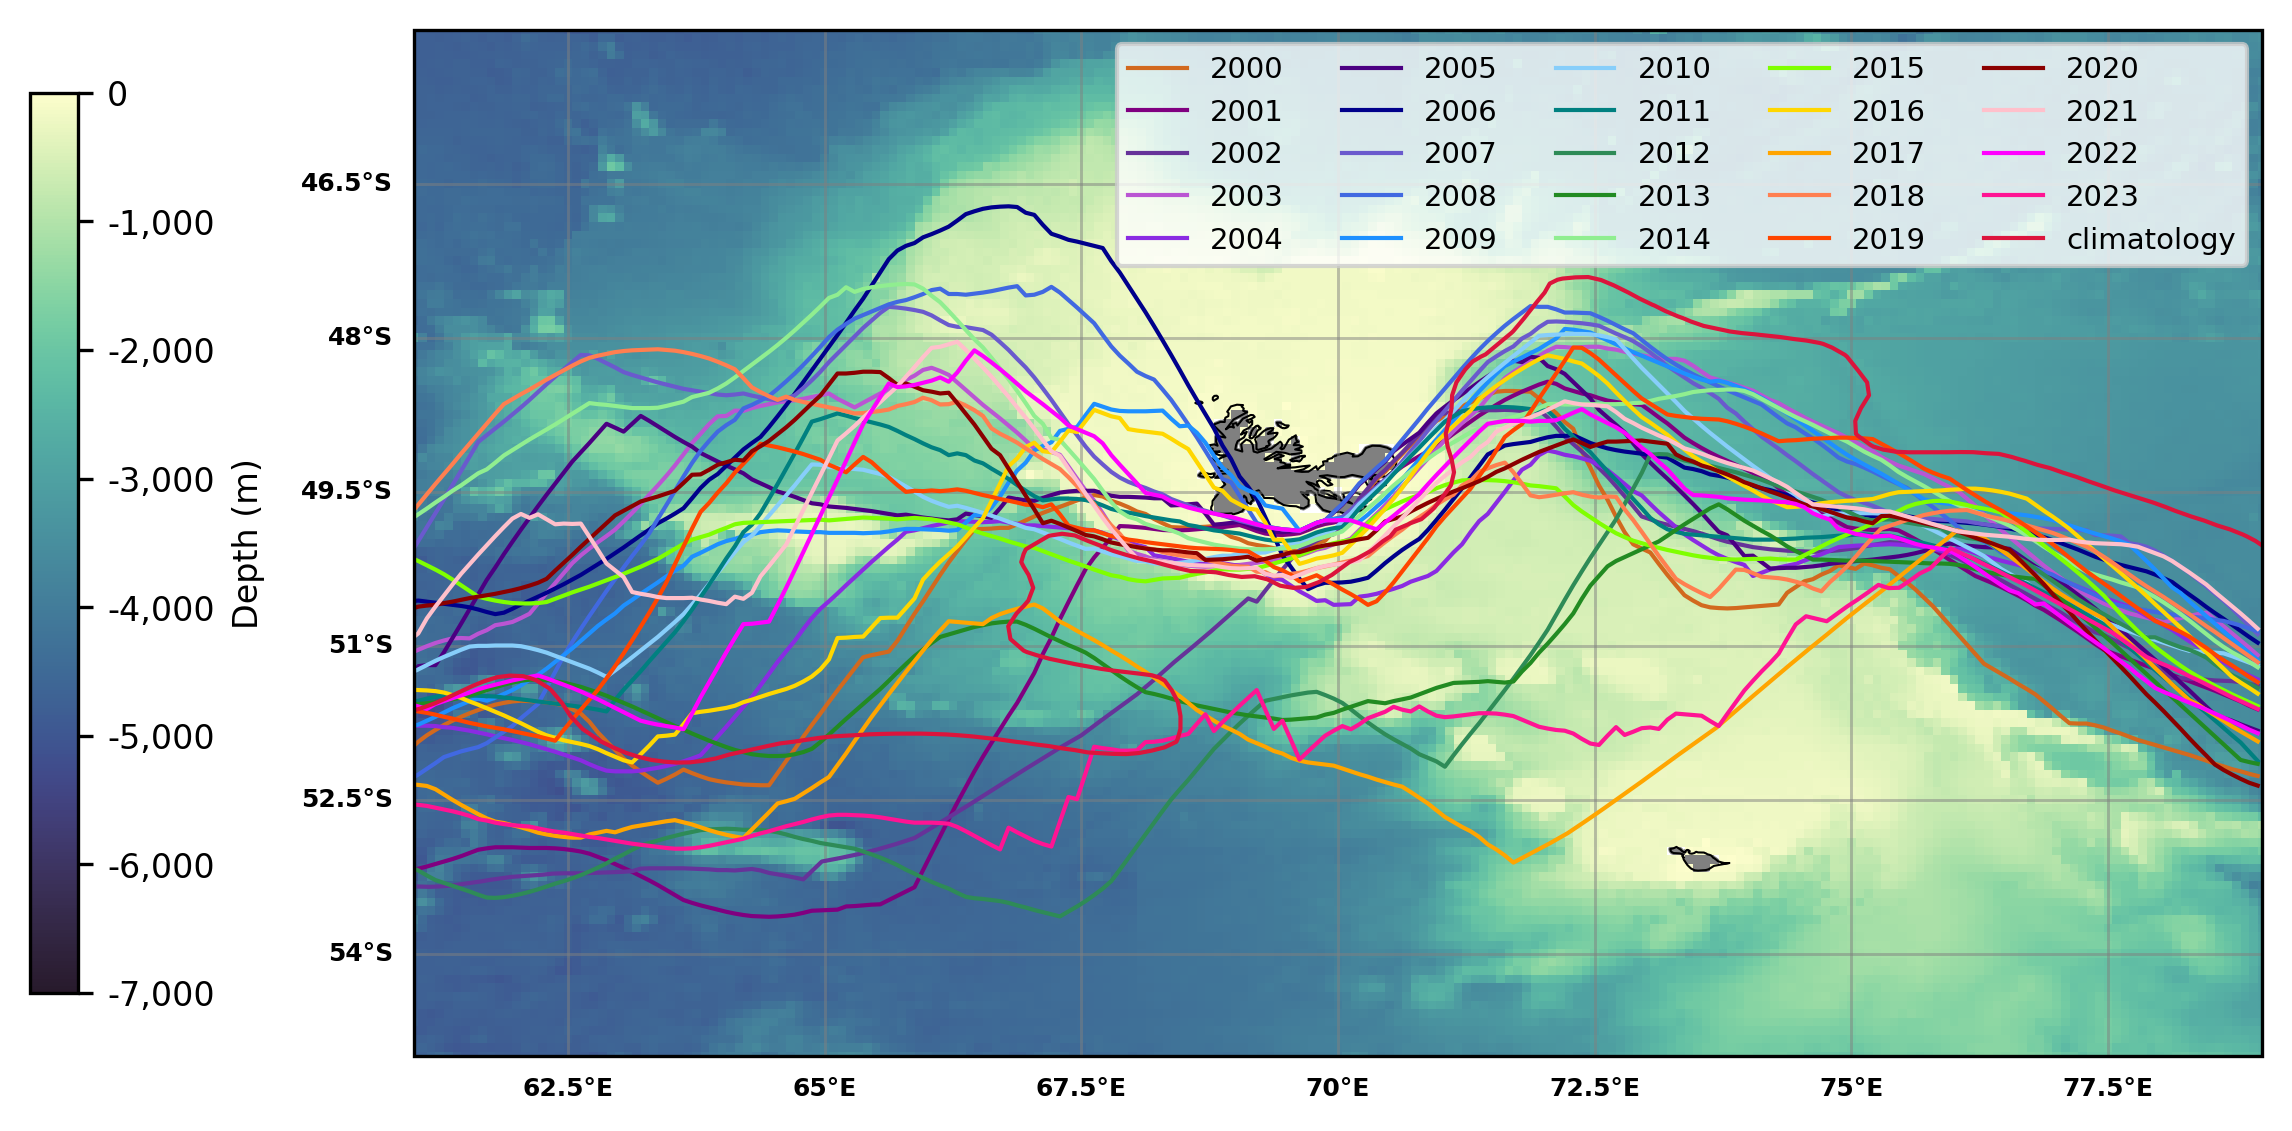

In [32]:
colors=['chocolate','purple','rebeccapurple','mediumorchid','blueviolet','indigo','darkblue','slateblue','royalblue','dodgerblue','lightskyblue','teal','seagreen','forestgreen','lightgreen','chartreuse','gold','orange','coral','orangered','darkred','pink','magenta','deeppink']

X,Y=np.meshgrid(lon,lat)
req_dpi=300

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},figsize=(8,5),dpi=req_dpi)


gl = ax.gridlines(crs=ccrs.PlateCarree(),
                  linewidth=0.7, color='gray', alpha=0.5)

gl.bottom_labels=True
gl.left_labels = True  

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.ylabel_style = {'size': 6, 'color': 'black','weight':'semibold'}
gl.xlabel_style = {'size':6,'color': 'black', 'weight': 'semibold'}

ax.add_feature(cartopy.feature.LAND,color='grey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

proj = ccrs.PlateCarree(central_longitude=70) # longitude "médiane" de la carte
ax.set_extent([-9,9,-55,-45],crs=proj)
im_bathy=ax.pcolormesh(X,Y,bathy_mask,transform=ccrs.PlateCarree(),vmin=-7000,vmax=0,cmap=cmocean.cm.deep_r)


for i,year in enumerate(year_list):
    
    df=pd.read_csv(rep+'position_PF_{}_week_25-29.csv'.format(year))
    lon_pf=df['lon_PF']
    lat_pf=df['lat_PF']
    
    ax.plot(lon_pf,lat_pf,transform=ccrs.PlateCarree(),linewidth=1,color=colors[i],label=year)


ax.plot(lon_pf_array[:],lat_pf_array[:],linewidth=1,color='crimson',transform=ccrs.PlateCarree(),label='climatology')

ax.legend(loc='upper right',fontsize=7,ncol=5)

cbar_ax = fig.add_axes([0.02, 0.2, 0.02, 0.6])
cbar=fig.colorbar(im_bathy,cax=cbar_ax,orientation='vertical',ticks=[-7000,-6000,-5000,-4000,-3000, -2000,-1000,0])
cbar.set_label('Depth (m)',fontsize=8)
cbar.ax.set_yticklabels(['-7,000','-6,000','-5,000','-4,000','-3,000', '-2,000','-1,000','0'],fontsize=8)
fig.set_dpi(req_dpi)

fig.subplots_adjust(bottom=0.05, top=0.95, left=0.18, right=0.95,hspace=0.1)